## Metadata formatting

earthkit-plots supports **metadata-aware format strings** in titles, legend labels, and axis
labels.  Curly-brace placeholders like `{variable_name}` or `{time:%B %Y}` are automatically
populated from the data's metadata — regardless of whether it comes from a GRIB file, a
netCDF/xarray dataset, or a plain NumPy array with a `metadata=` dict.

This notebook covers:

- How metadata is read from xarray (variable attrs, global attrs, scalar coordinates, and the
  variable name itself)
- What `{variable_name}` looks for and why it is a *magic* key
- Accessing singleton dimension values in format strings (e.g. `{latitude}` for a single-point
  time series)
- Overriding metadata at plot time with the `metadata=` argument
- Using any arbitrary attribute key in a format string
- How earthkit-plots deduplicates values across layers
- Location formatters for point data

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp

### A quick example

Before diving into the details, here is what the feature looks like in practice.  We load a
GRIB file containing two fields — 2 m temperature and mean sea-level pressure — and plot them
together.  All placeholders in the title and legend label are resolved automatically:

In [2]:
data = ekd.from_source("sample", "era5-2t-msl-1985122512.grib").to_fieldlist()
temperature, pressure = data

temp_style = ekp.styles.Style(
    levels=range(-20, 21, 2), colors="Spectral_r", units="celsius", extend="both",
)
pressure_style = ekp.styles.Contour(
    levels={"step": 4}, colors="black", units="hPa",
    linewidths=[0.25, 0.25, 0.25, 0.75], labels=True, legend_style=None,
)

chart = ekp.Map(domain="North Atlantic")
chart.contourf(temperature, style=temp_style)
chart.contour(pressure, style=pressure_style)
chart.legend(label="{variable_name} ({units})")
chart.coastlines()
chart.borders()
chart.gridlines()
chart.title("ERA5 {variable_name} at {time:%H:%M UTC on %d %b %Y}")
chart.show()

### How metadata is read from xarray

When you pass an `xr.DataArray` or `xr.Dataset`, earthkit-plots searches for metadata in a
fixed priority order:

1. **Variable-level `attrs`** — the `attrs` dictionary of the selected `DataArray`
   (e.g. `long_name`, `units`, `standard_name`).
2. **Scalar coordinate values** — if a coordinate with the same name as the key exists
   and has no dimensions (a *singleton coordinate*), its value is returned.  This is how
   `{latitude}` and `{longitude}` work for single-point data (see below).
3. **The variable name itself** — for the special key `"name"`, earthkit-plots falls back
   to `da.name` (the name of the `DataArray` in its parent `Dataset`).
4. **Dataset-level global `attrs`** — keys like `institution` or `Conventions` stored on
   the `Dataset` object are visible to all variables in that dataset.

Let's inspect what the xarray representation of the ERA5 temperature file looks like:

In [3]:
ds = ekd.from_source("sample", "era5-monthly-mean-2t-199312.grib").to_xarray()
ds

<xarray.Dataset> Size: 8MB
Dimensions:    (latitude: 721, longitude: 1440)
Coordinates:
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    2t         (latitude, longitude) float64 8MB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

The dataset carries **global attrs** (`Conventions`, `institution`) at the dataset level, and
the variable `t2m` carries its own **variable attrs**. All of these are accessible in format strings.  Here we use `{institution}` from the global attrs and `{variable_name}` from the variable attrs:

In [4]:
chart = ekp.Map(domain="Europe")
chart.contourf(ds, units="celsius", style="auto")
chart.coastlines()
chart.legend(label="{variable_name} ({units})")
chart.title("{variable_name}")
chart.attribution("Source: {institution}", location="lower right")
chart.show()

### `{variable_name}` is a magic key

`{variable_name}` is not an ordinary attribute lookup - it is a *magic key* that searches
several candidate attributes in priority order until it finds one that is set:

```
long_name  →  standard_name  →  name  →  short_name
```

The `name` entry in that chain is special: for xarray data it falls back to the name of the
`DataArray` itself (e.g. `"t2m"`).  Underscores in the result are automatically replaced with
spaces, so `"2m_temperature"` becomes `"2m temperature"`.

This means `{variable_name}` works correctly across GRIB, netCDF, xarray, and NumPy data
without any extra configuration - and you can still override it by setting `long_name` on
your `DataArray` or by passing `metadata={"long_name": "..."}` at plot time.

Other magic keys that follow the same pattern:

| Key | Searches |
|-----|----------|
| `{variable_name}` | `long_name`, `standard_name`, `name`, `short_name` |
| `{ensemble_member}` | `ensemble_member`, `realization`, `number`, `ensemble`, `member` |
| `{location}` | Reverse geocoding from lat/lon (requires `reverse-geocode`) |

### Singleton values in format strings

When a coordinate has only a single value - either because it was always scalar or because
you selected a particular slice - earthkit-plots makes that value available as a format key
with the coordinate's name.

This is most useful for single-point time series, where the `latitude` and `longitude`
coordinates are scalars.  The ERA5 Reading time series sample is a good example:

In [5]:
era5_ts = ekd.from_source("sample", "era5-reading-timeseries.nc").to_xarray()

# latitude and longitude are scalar coordinates — no dimension
print("latitude :", era5_ts.coords["latitude"].values)
print("longitude:", era5_ts.coords["longitude"].values)

latitude : 51.5
longitude: -1.0


Because they are scalar coordinates, we can use `{latitude}` and `{longitude}` directly
in format strings.  The `%Lt` and `%Ln` format specifiers add the degree symbol and N/S or
E/W direction:

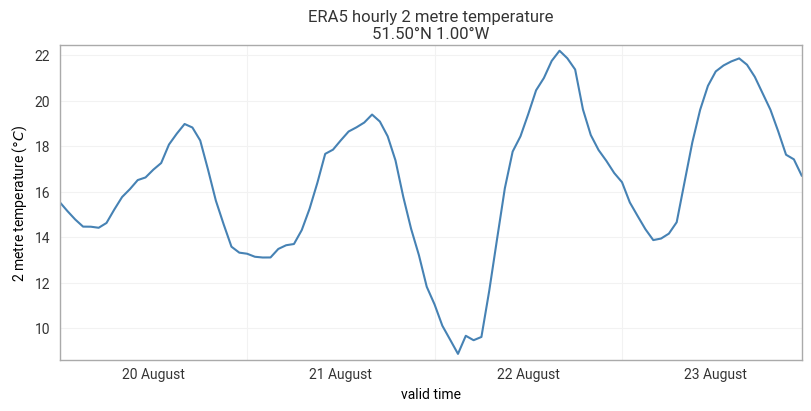

In [6]:
(
    ekp.timeseries.line(era5_ts, color="steelblue", units="celsius")
    .title(
        "ERA5 hourly {variable_name}\n"
        "{latitude:%Lt} {longitude:%Ln}"
    )
    .xticks(frequency="D", format="%d %B", period=True)
    .show()
)

The same mechanism applies to any singleton coordinate.  If you select a single pressure
level from a multi-level dataset, `{pressure_level}` (or whatever the coordinate is called)
will automatically resolve to that value.

### Overriding metadata at plot time

Pass `metadata=` to any plotting method to inject or override key/value pairs.  The dict
takes precedence over all file-level attributes, making it useful both for data that lacks
metadata (NumPy arrays) and for annotating an existing dataset with extra context.

In [7]:
from datetime import datetime

fl = ekd.from_source("sample", "era5-monthly-mean-2t-199312.grib").to_fieldlist()
lats, lons = fl.geography.latlons()
t2m = fl.to_numpy().squeeze()

meta = {
    "units": "K",
    "long_name": "2 metre temperature",
    "time": datetime(1993, 12, 1),
    "institution": "ECMWF",
}

chart = ekp.Map(domain="Europe")
chart.contourf(t2m, x=lons, y=lats, metadata=meta, units="celsius", style="auto")
chart.coastlines()
chart.legend(label="{variable_name} ({units})")
chart.title("{variable_name} – {time:%B %Y}")
chart.attribution("Source: {institution}", location="lower right")
chart.show()

### Deduplication

When a chart has multiple layers, earthkit-plots collects the resolved value of each
format key from every layer and applies a simple rule:

- **If all layers agree on a value**, it is shown once.
- **If layers disagree**, the distinct values are joined into a human-readable list
  (e.g. `"2 metre temperature and Mean sea level pressure"`).

This is why `{time}` appears only once in the example below (both
fields share the same valid time), while `{variable_name}` lists both variables.

The same logic applies to legend labels, but there each label is resolved independently
per layer — so `{variable_name}` in a legend label always expands to the name of the
single field it belongs to.

In [8]:
chart = ekp.Map(domain="North Atlantic")
chart.contourf(temperature, style=temp_style)
chart.contour(pressure, style=pressure_style)
chart.legend(label="{variable_name} ({units})")
chart.coastlines()
chart.borders()
chart.gridlines()
chart.title("ERA5 {variable_name} at {time:%H:%M UTC on %d %b %Y}")
chart.show()

### Location formatters

For single-point data the scalar `latitude` and `longitude` coordinates can be formatted
with human-readable specifiers:

| Specifier | Example output | Notes |
|-----------|----------------|-------|
| `{latitude:%Lt}` | `51.46°N` | Default 2 d.p.; use `%Lt.0` for no decimals |
| `{longitude:%Ln}` | `0.94°W` | Default 2 d.p. |
| `{location:%c}` | `Reading` | City name — requires `reverse-geocode` |
| `{location:%C}` | `United Kingdom` | Country name — requires `reverse-geocode` |

> **Note:** `{location}` requires the optional
> [`reverse-geocode`](https://pypi.org/project/reverse-geocode/) package
> (`pip install reverse-geocode`).  Without it, use `{latitude:%Lt} {longitude:%Ln}`
> as a fallback.

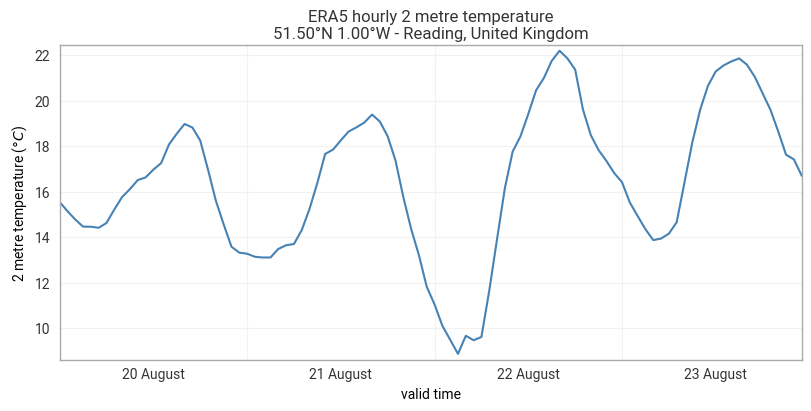

In [9]:
(
    ekp.timeseries.line(era5_ts, color="steelblue", units="celsius")
    .title(
        "ERA5 hourly {variable_name}\n"
        "{latitude:%Lt} {longitude:%Ln} - "
        "{location:%c}, {location:%C}"
    )
    .xticks(frequency="D", format="%d %B", period=True)
    .show()
)

### Quick reference

| Key | What it resolves to |
|-----|---------------------|
| `{variable_name}` | Human-readable variable name — searches `long_name`, `standard_name`, `name`, `short_name` |
| `{units}` | Units after any conversion applied at plot time |
| `{time:%d %B %Y}` | Valid time, formatted with standard `strftime` codes |
| `{base_time}` / `{valid_time}` | Forecast base time and valid time |
| `{lead_time}` | Forecast lead time in hours |
| `{domain}` | Name of the map domain (named domains only) |
| `{crs}` | Name of the map projection |
| `{latitude:%Lt}` | Latitude with degree symbol and N/S direction |
| `{longitude:%Ln}` | Longitude with degree symbol and E/W direction |
| `{location:%c}` | City name (requires `reverse-geocode`) |
| `{location:%C}` | Country name (requires `reverse-geocode`) |
| `{ensemble_member}` | Ensemble member number |
| `{<any attr>}` | Any key present in the data's metadata |